In [7]:
import numpy as np
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix
from sklearn.feature_selection import f_classif
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import rasterio

In [3]:
TRAIN_LOCS_KEY = 'train_locs'
TRAIN_IDS_KEY = 'train_ids'
TAXON_IDS_KEY = 'taxon_ids'
TAXON_NAME_KEY = 'taxon_names'

TEST_LOCS_KEY = 'test_locs'
TEST_IDS_KEY = 'test_pos_inds'

Reading the file:

In [8]:
filepath = os.path.join(os.getcwd(), '/Users/Maya/Desktop/species/species_train.npz')
data = np.load(filepath, allow_pickle=True)
train_locs = data[TRAIN_LOCS_KEY]
train_ids = data[TRAIN_IDS_KEY]
taxon_ids = data[TAXON_IDS_KEY]
taxon_names = data[TAXON_NAME_KEY]

Reading the test file:

In [9]:
test_filepath = os.path.join(os.getcwd(), '/Users/Maya/Desktop/species/species_test.npz')
test_data = np.load(test_filepath, allow_pickle=True)
test_locs = test_data[TEST_LOCS_KEY]
test_ids = test_data[TEST_IDS_KEY]

Mapping the taxon ids to taxon latin names: 

In [10]:
species_ids_names = dict(zip(data['taxon_ids'], data['taxon_names']))  # latin names of species 

Create pandas Dataframe from the train data: 

In [11]:
df = pd.DataFrame({
    'latitude': train_locs[:, 0],
    'longitude': train_locs[:, 1], 
    'taxon_id': data[TRAIN_IDS_KEY]
})
df['taxon_name'] = [species_ids_names[id] for id in data[TRAIN_IDS_KEY].astype(int)]
df.head()

,latitude,longitude,taxon_id,taxon_name
0,-18.286728,143.481247,31529,Lophognathus gilberti
1,-13.099798,130.783646,31529,Lophognathus gilberti
2,-13.965274,131.695145,31529,Lophognathus gilberti
3,-12.853950,132.800507,31529,Lophognathus gilberti
4,-12.196790,134.279327,31529,Lophognathus gilberti


Create pandas Dataframe from the test data: 

In [12]:
rows = [
    [test_locs[loc_id][0], test_locs[loc_id][1], taxon_id]
    for taxon_id, loc_ids in zip(taxon_ids, test_ids)
    for loc_id in loc_ids
]

In [13]:
test_df = pd.DataFrame(rows, columns=["latitude", "longitude", "taxon_id"])
test_df['taxon_name'] = [species_ids_names[id] for id in test_df["taxon_id"].astype(int)]
test_df.head()

,latitude,longitude,taxon_id,taxon_name
0,-19.884237,126.052979,31529,Lophognathus gilberti
1,-20.219316,124.723953,31529,Lophognathus gilberti
2,-20.053690,125.386505,31529,Lophognathus gilberti
3,-19.973000,126.462440,31529,Lophognathus gilberti
4,-19.962839,124.980362,31529,Lophognathus gilberti


In [14]:
test_df.shape

(1706646, 4)

Data Cleanining: 

<small>1. Check for missing or invalid coordinates:</small>

In [15]:
df = df.dropna(subset=['latitude', 'longitude'])
test_df = test_df.dropna(subset=['latitude', 'longitude'])
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]
test_df = test_df[(test_df['latitude'].between(-90, 90)) & (test_df['longitude'].between(-180, 180))]
df.shape, test_df.shape

((272037, 4), (1706646, 4))

<small>2. Remove any duplicates or nearly duplicates (observations that are extremely close):</small>

In [16]:
df['lat_rounded'] = df['latitude'].round(5)
df['lon_rounded'] = df['longitude'].round(5)
test_df['lat_rounded'] = test_df['latitude'].round(5)
test_df['lon_rounded'] = test_df['longitude'].round(5)

In [17]:
df = df.drop_duplicates(subset=['lat_rounded', 'lon_rounded','taxon_id'])
test_df = test_df.drop_duplicates(subset=['lat_rounded', 'lon_rounded','taxon_id'])
df.shape, test_df.shape

((251822, 6), (1706646, 6))

<small>4. Validate species IDs: </small>

In [18]:
df['taxon_id'].isna().sum(), test_df['taxon_id'].isna().sum()

(np.int64(0), np.int64(0))

<small>5. Only keep birds:</small>

<small>Note: Only run the next 2 blocks one time as they take a few seconds:</small>

In [19]:
taxa = pd.read_csv('/Users/Maya/Desktop/species/taxa.csv')
birds = taxa[taxa['class'] == 'Aves']
bird_taxon_ids = set(birds['id'])
len(bird_taxon_ids)

32140

In [20]:
df = df[df['taxon_id'].isin(bird_taxon_ids)].copy()
test_df = test_df[test_df['taxon_id'].isin(bird_taxon_ids)].copy()
df.shape, test_df.shape

((162642, 6), (1323320, 6))

<small>6. Convert to categorical labels:</small>

In [21]:
le = LabelEncoder()
le.fit(pd.concat([df['taxon_id'], test_df['taxon_id']]))
df['label'] = le.transform(df['taxon_id'])
test_df['label'] = le.transform(test_df['taxon_id'])

<small>7. Append the climate data</small>

In [23]:
base_dir = os.getcwd()  # assumes folders are in the same directory as this notebook

def load_stack(folder_name):
    folder = os.path.join(base_dir, folder_name)
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".tif")])
    if len(files) != 12:
        raise RuntimeError(f"Expected 12 GeoTIFFs in {folder_name}, found {len(files)}.")
    layers = []
    transform = None
    for f in files:
        with rasterio.open(f) as src:
            layers.append(src.read(1))
            transform = src.transform  # all months share the same transform
    return np.stack(layers), transform  # shape: (12, H, W), and affine transform

tmin, transform = load_stack('/Users/Maya/Desktop/species/wc2.1_2.5m_tmin')
tmax, _         = load_stack('/Users/Maya/Desktop/species/wc2.1_2.5m_tmax')
prec, _         = load_stack('/Users/Maya/Desktop/species/wc2.1_2.5m_prec')

print("Stacks loaded. Shapes:",
      "tmin", tmin.shape, "tmax", tmax.shape, "prec", prec.shape)
print("Transform:", transform)

Stacks loaded. Shapes: tmin (12, 4320, 8640) tmax (12, 4320, 8640) prec (12, 4320, 8640)
Transform: | 0.04, 0.00,-180.00|
| 0.00,-0.04, 90.00|
| 0.00, 0.00, 1.00|


In [24]:
#Cleaning the data again as the precipitation values are very large, so I'll normalize them
from rasterio.transform import rowcol
import numpy as np

def get_climate_for_points(df, transform, tmin, tmax, prec, lat_col="latitude", lon_col="longitude"):
    # Convert lat/lon → raster indices
    rows, cols = rowcol(transform, df[lon_col].values, df[lat_col].values)
    rows = np.clip(rows, 0, tmin.shape[1]-1)
    cols = np.clip(cols, 0, tmin.shape[2]-1)

    # Helper: clean up weird values (NoData etc.)
    def clean(arr):
        arr = arr.astype(float)
        arr[arr > 1e4] = np.nan  # remove unrealistic large values
        return arr

    tmin = clean(tmin)
    tmax = clean(tmax)
    prec = clean(prec)

    # Extract values and average across 12 months safely
    tmin_mean = np.nanmean(tmin[:, rows, cols], axis=0)
    tmax_mean = np.nanmean(tmax[:, rows, cols], axis=0)
    prec_mean = np.nanmean(prec[:, rows, cols], axis=0)

    return tmin_mean, tmax_mean, prec_mean

In [25]:
tmin_avg, tmax_avg, prec_avg = get_climate_for_points(df, transform, tmin, tmax, prec)

In [26]:
test_tmin_avg, test_tmax_avg, test_prec_avg = get_climate_for_points(test_df, transform, tmin, tmax, prec)

In [27]:
df["Tmin_avg"] = tmin_avg
df["Tmax_avg"] = tmax_avg
df["Prec_avg"] = prec_avg

df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]].head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
53,21.086105,-86.852867,20.967000,31.436000,103.416667
54,19.186003,-96.199600,19.327333,31.831333,117.833333
55,17.538877,-89.113724,19.496333,30.576333,125.583333
56,20.648556,-105.220955,19.674123,31.835527,87.750000
57,18.409698,-95.096657,20.515000,29.086000,156.750000


In [28]:
test_df["Tmin_avg"] = test_tmin_avg
test_df["Tmax_avg"] = test_tmax_avg
test_df["Prec_avg"] = test_prec_avg

test_df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]].head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
784,19.289352,-89.842888,1.885033e+01,3.272100e+01,91.750000
785,20.777590,-88.534241,1.882467e+01,3.272433e+01,103.833333
786,21.513868,-86.804565,2.165833e+01,3.071667e+01,100.250000
787,18.710384,-94.898964,-3.400000e+38,-3.400000e+38,-32768.000000
788,21.509193,-88.522995,1.973447e+01,3.149773e+01,73.250000


In [29]:
out_path = "bird_species_rerun_with_averaged_climate.csv"
df.to_csv(out_path, index=False)
out_path, df.shape

('bird_species_rerun_with_averaged_climate.csv', (162642, 10))

In [30]:
out_path = "test_bird_species_rerun_with_averaged_climate.csv"
test_df.to_csv(out_path, index=False)
out_path, test_df.shape

('test_bird_species_rerun_with_averaged_climate.csv', (1323320, 10))

In [31]:
df = pd.read_csv('bird_species_rerun_with_averaged_climate.csv')

In [32]:
test_df = pd.read_csv('test_bird_species_rerun_with_averaged_climate.csv')

<small>8. Clean the climate data</small>

In [33]:
df['Tmin_avg'] = df['Tmin_avg'].mask(df['Tmin_avg'] < -1e+30, np.nan)
df['Tmax_avg'] = df['Tmax_avg'].mask(df['Tmax_avg'] < -1e+30, np.nan)
df['Prec_avg'] = df['Prec_avg'].mask(df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {df.shape}")
df = df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {df.shape}")

Shape with nan data: (162642, 10)
Shape without nan data: (161432, 10)


In [74]:
len(test_df)

1323320

In [34]:
test_df['Tmin_avg'] = test_df['Tmin_avg'].mask(test_df['Tmin_avg'] < -1e+30, np.nan)
test_df['Tmax_avg'] = test_df['Tmax_avg'].mask(test_df['Tmax_avg'] < -1e+30, np.nan)
test_df['Prec_avg'] = test_df['Prec_avg'].mask(test_df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {test_df.shape}")
test_df = test_df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {test_df.shape}")

Shape with nan data: (1323320, 10)
Shape without nan data: (928354, 10)


<small>Note: mention in the report that we lost a lot of data because of removing NaN temperature, in the ociens mainly.</small>

In [76]:
(df['Tmax_avg'] < df['Tmin_avg']).sum(), (test_df['Tmax_avg'] < test_df['Tmin_avg']).sum()

(np.int64(0), np.int64(0))

<small>Add sin feature to capture circularity</small>

In [35]:
df['lat_sin'] = np.sin(np.deg2rad(df['latitude']))
df['lat_cos'] = np.cos(np.deg2rad(df['latitude']))
df['lon_sin'] = np.sin(np.deg2rad(df['longitude']))
df['lon_cos'] = np.cos(np.deg2rad(df['longitude']))

In [36]:
test_df['lat_sin'] = np.sin(np.deg2rad(test_df['latitude']))
test_df['lat_cos'] = np.cos(np.deg2rad(test_df['latitude']))
test_df['lon_sin'] = np.sin(np.deg2rad(test_df['longitude']))
test_df['lon_cos'] = np.cos(np.deg2rad(test_df['longitude']))

In [37]:
df.shape, test_df.shape

((161432, 14), (928354, 14))

<small>9. Split the data to x and y and normalize the climate features</small>

In [38]:
X_data = df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_data = df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
scaler = StandardScaler()
scaler.fit(X_data[climate_features])
X_scaled = X_data.copy()
X_scaled[climate_features] = scaler.transform(X_data[climate_features])
X_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos
count,161432.000000,161432.000000,1.614320e+05,1.614320e+05,1.614320e+05,161432.000000,161432.000000,161432.000000,161432.000000
mean,14.827329,-8.036515,-6.197310e-17,2.929638e-16,3.098655e-17,0.230808,0.820155,-0.203034,0.042523
std,31.900029,95.705462,1.000003e+00,1.000003e+00,1.000003e+00,0.509097,0.122050,0.770315,0.602984
min,-75.284950,-178.060320,-6.699036e+00,-6.690300e+00,-1.635481e+00,-0.967201,0.254012,-1.000000,-0.999791
25%,-21.050622,-96.105056,-6.488781e-01,-7.633616e-01,-6.553056e-01,-0.359193,0.747490,-0.968077,-0.459039
50%,26.165924,-43.440056,1.560563e-02,1.265317e-01,-1.806941e-01,0.440972,0.831109,-0.673665,0.067571
75%,40.959681,75.385002,6.814487e-01,7.350146e-01,3.936545e-01,0.655528,0.914683,0.524633,0.545473
max,72.515430,178.827590,2.250907e+00,2.213666e+00,1.319785e+01,0.953798,1.000000,1.000000,1.000000


In [39]:
X_test = test_df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_test = test_df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
X_test_scaled = X_test.copy()
X_test_scaled[climate_features] = scaler.transform(X_test[climate_features])
X_test_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos
count,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000
mean,13.171677,13.497898,0.183610,0.289493,-0.008040,0.198286,0.853137,0.094081,0.314364
std,29.127638,77.380268,1.432959,1.412140,1.242831,0.455790,0.158418,0.745243,0.580464
min,-85.600830,-179.933670,-6.928313,-7.189774,-1.635481,-0.997054,0.076705,-1.000000,-1.000000
25%,-12.422070,-59.177242,-0.792492,-0.690674,-0.923564,-0.215112,0.773541,-0.837545,-0.177202
50%,11.103984,23.309443,0.622043,0.861617,-0.350935,0.192590,0.913240,0.389406,0.445380
75%,38.710465,74.511734,1.357427,1.342591,0.594849,0.625385,0.979165,0.720192,0.853618
max,82.845260,179.994780,2.595104,2.364347,12.102457,0.992213,1.000000,1.000000,1.000000


<small>9. Split to train and validation sets</small>

In [40]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_data,
                                                  test_size=0.2,
                                                  random_state=42, 
                                                  stratify=y_data)

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)

Exploratory Data Analysis:

#possible biases in the dataset(skewness)

In [41]:
print("Lat skewness:", df['latitude'].skew())
print("Long skewness:", df['longitude'].skew())

Lat skewness: -0.4843194974691385
Long skewness: 0.44562316816550696


# of unique species: 285
count Most common speciest: 1963
count Least common species: 42
Imbalance ratio (max:min): 46.73809523809524


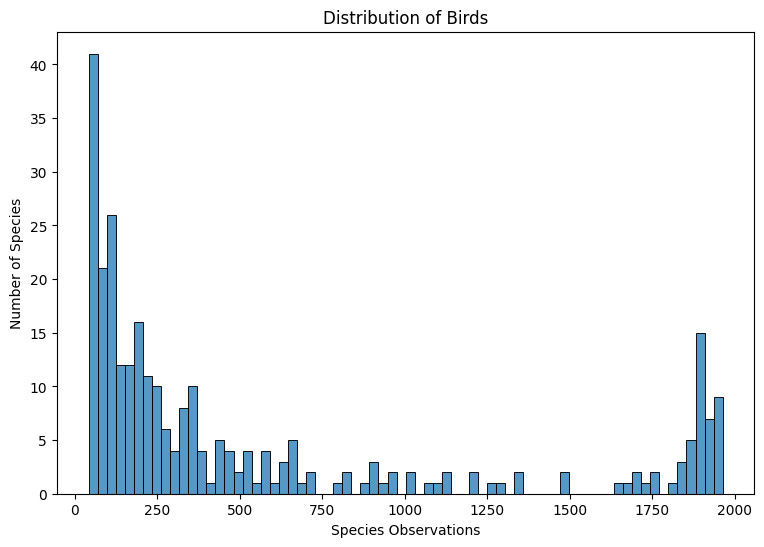

In [84]:
#dataset balance
species_counts = df['taxon_id'].value_counts()

print("# of unique species:", df['taxon_id'].nunique())
print("count Most common speciest:", species_counts.max())
print("count Least common species:", species_counts.min())
imbalance_ratio = species_counts.max() / species_counts.min()
print("Imbalance ratio (max:min):", imbalance_ratio)
plt.figure(figsize=(9,6))
sns.histplot(species_counts, bins=70)
plt.title('Distribution of Birds')
plt.xlabel('Species Observations')
plt.ylabel('Number of Species')
plt.show()

Correlation analysis

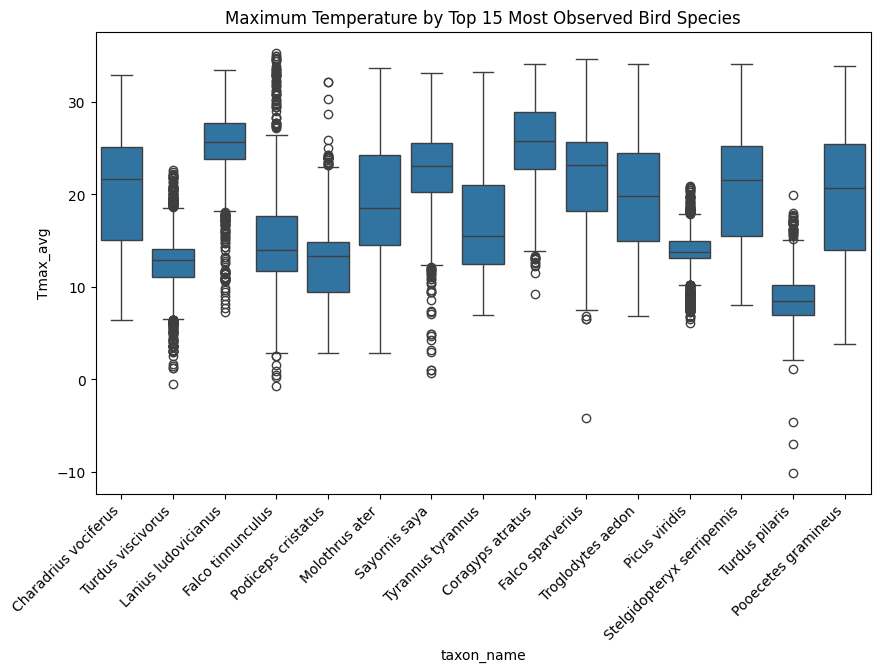

In [82]:
# choose the top 15 species to do the analysis on MAX temp
top_species = df['taxon_name'].value_counts().head(15).index
df_top15 = df[df['taxon_name'].isin(top_species)]
plt.figure(figsize=(10,6))
sns.boxplot(x='taxon_name', y='Tmax_avg', data=df_top15)
plt.xticks(rotation=45, ha='right')
plt.title('Maximum Temperature by Top 15 Most Observed Bird Species')
plt.show()

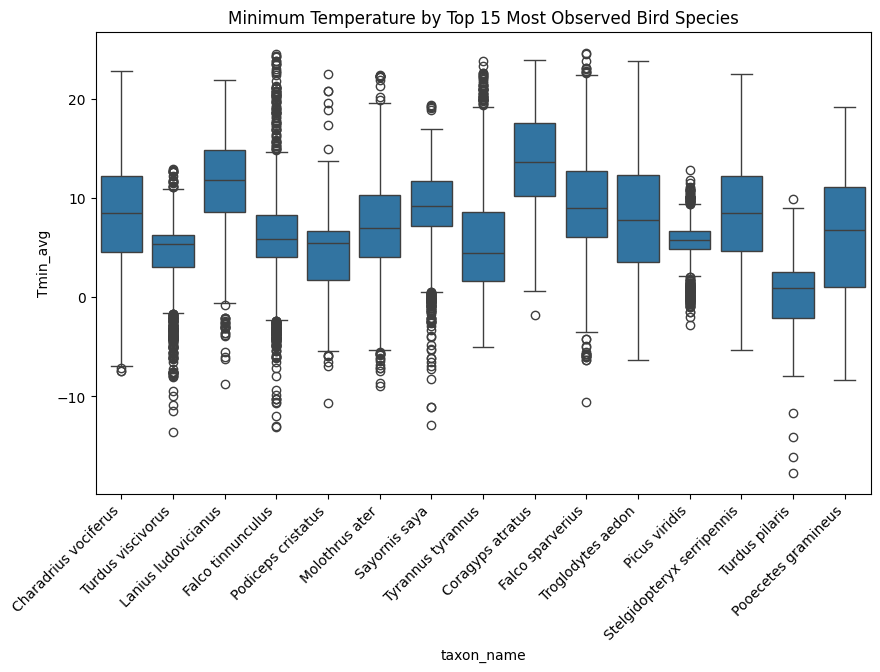

In [83]:
# choose the top 15 species to do the analysis on Min Temp
top_species = df['taxon_name'].value_counts().head(15).index
df_top15 = df[df['taxon_name'].isin(top_species)]
plt.figure(figsize=(10,6))
sns.boxplot(x='taxon_name', y='Tmin_avg', data=df_top15)
plt.xticks(rotation=45, ha='right')
plt.title('Minimum Temperature by Top 15 Most Observed Bird Species')
plt.show()

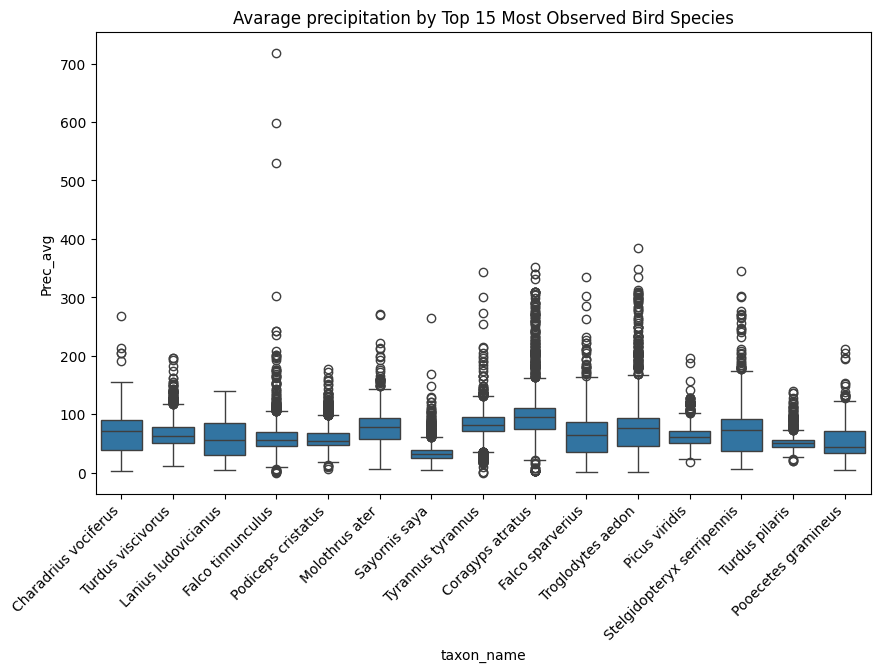

In [84]:
# choose the top 15 species to do the analysis on Avarage precipitation
top_species = df['taxon_name'].value_counts().head(15).index
df_top15 = df[df['taxon_name'].isin(top_species)]
plt.figure(figsize=(10,6))
sns.boxplot(x='taxon_name', y='Prec_avg', data=df_top15)
plt.xticks(rotation=45, ha='right')
plt.title('Avarage precipitation by Top 15 Most Observed Bird Species')
plt.show()

feature-feature relationships

Text(0.5, 1.0, 'Correlation Matrix of Climatic Variables')

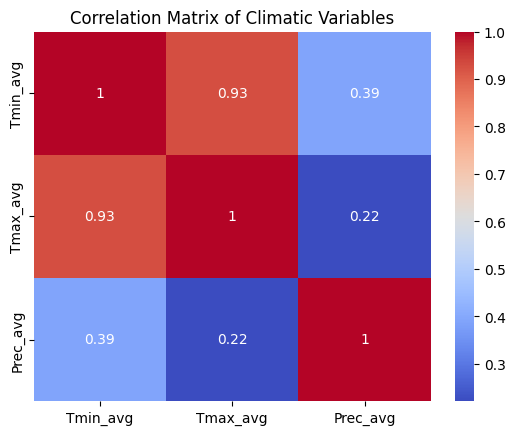

In [41]:
corr = df[['Tmin_avg', 'Tmax_avg', 'Prec_avg']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Climatic Variables')

ANOVA F-scores

In [86]:
# Encode species numerically if it's strings
X = df[['Tmin_avg', 'Tmax_avg']]
y = df['taxon_id']

y_enc = LabelEncoder().fit_transform(y)

# ANOVA F-value
f_scores, p_values = f_classif(X, y_enc)
print("ANOVA F-scores:", f_scores)

ANOVA F-scores: [1304.72588461 1473.29925794]


In [87]:
df['lat_round'] = df['latitude'].round(1)
df['lon_round'] = df['longitude'].round(1)

abundance = df.groupby(['lat_round', 'lon_round']).size().reset_index(name='count')
abundance.head()

,lat_round,lon_round,count
0,-75.3,-102.7,1
1,-75.3,-0.1,1
2,-67.6,-68.1,1
3,-65.9,-66.2,1
4,-65.1,-64.0,2


C:\Users\hajir\AppData\Local\Temp\ipykernel_14940\2466296275.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Spatial Distribution by Top 5 Bird Species')

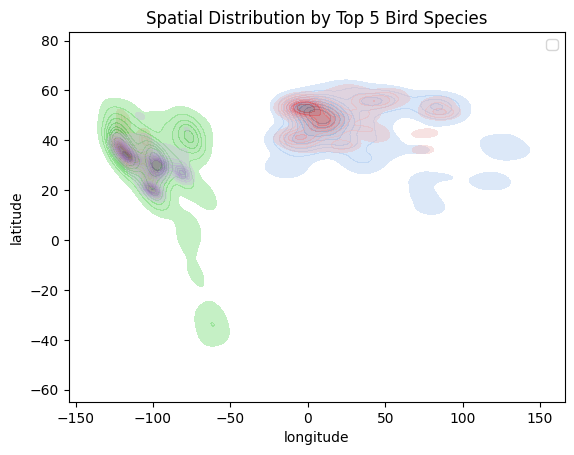

In [89]:
top_species = df['taxon_name'].value_counts().head(5).index
for species in top_species:
    subset = df[df['taxon_name'] == species]
    sns.kdeplot(x=subset['longitude'], y=subset['latitude'], fill=True, label=species, alpha=0.4)
plt.legend()
plt.title('Spatial Distribution by Top 5 Bird Species')

logistic regression Model

In [42]:
log_reg = LogisticRegression(solver='saga', max_iter=800, tol=1e-3,
                             class_weight='balanced', C=5.0, n_jobs=-1)

In [43]:
# Train (fit) the model
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.001
,C,5.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'saga'
,max_iter,800
,multi_class,'deprecated'


In [44]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = log_reg.predict(X_val)
print("Train acc:", log_reg.score(X_train, y_train))
print("Val  acc:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred, zero_division=0))

Train acc: 0.14863138332881645
Val  acc: 0.1489144237618856
              precision    recall  f1-score   support

           0       0.11      0.19      0.14        47
           1       0.17      0.56      0.26        71
           2       0.00      0.00      0.00       227
           3       0.31      0.85      0.46        13
           4       0.02      0.20      0.04        10
           5       0.21      0.44      0.29        16
           6       0.22      0.70      0.34       375
           7       0.08      0.42      0.14       106
           8       0.03      1.00      0.05        13
           9       0.08      0.40      0.13        10
          10       0.11      0.84      0.19        64
          11       0.07      0.03      0.04        68
          12       0.10      0.36      0.16        87
          13       0.06      0.01      0.01       137
          14       0.11      0.02      0.04        43
          15       0.06      0.10      0.07        42
          16       0.

In [45]:
y_test_pred = log_reg.predict(X_test_scaled)
y_test_proba = log_reg.predict_proba(X_test_scaled)

In [46]:
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Top-5 accuracy:", top_k_accuracy_score(y_test, y_test_proba, k=5))
print("\nClassification Report (Test):\n")
print(classification_report(y_test, y_test_pred, zero_division=0))

Test accuracy: 0.05377474540961745
Top-5 accuracy: 0.23991925493938734

Classification Report (Test):

              precision    recall  f1-score   support

           0       0.03      0.04      0.04       593
           1       0.07      0.13      0.09      2217
           2       0.00      0.00      0.00      2877
           3       0.06      0.57      0.11       685
           4       0.07      0.10      0.08       791
           5       0.03      0.01      0.01       625
           6       0.08      0.20      0.11      4860
           7       0.09      0.35      0.14      6866
           8       0.01      0.59      0.03       253
           9       0.04      0.06      0.05      2990
          10       0.03      0.66      0.06       814
          11       0.03      0.03      0.03      3987
          12       0.03      0.01      0.01      1643
          13       0.03      0.00      0.00      1489
          14       0.03      0.01      0.02       277
          15       0.03      0.0

Evaluation:

1 ROC AUC: In a "One vs All" Setting sice our data assumes (presence, pesudoabsence)

In [50]:
from sklearn.metrics import roc_auc_score
import numpy as np

classes = np.unique(y_test)
auc_per_class = []

for i, cls in enumerate(classes):
    # true binary labels for this class
    y_true_binary = (y_test == cls).astype(int)

    # predicted probabilities for this class
    y_score = y_test_proba[:, i]

    # compute AUC
    auc = roc_auc_score(y_true_binary, y_score)
    auc_per_class.append(auc)

print("Mean ROC-AUC across classes:", np.mean(auc_per_class))


Mean ROC-AUC across classes: 0.9483036231268164


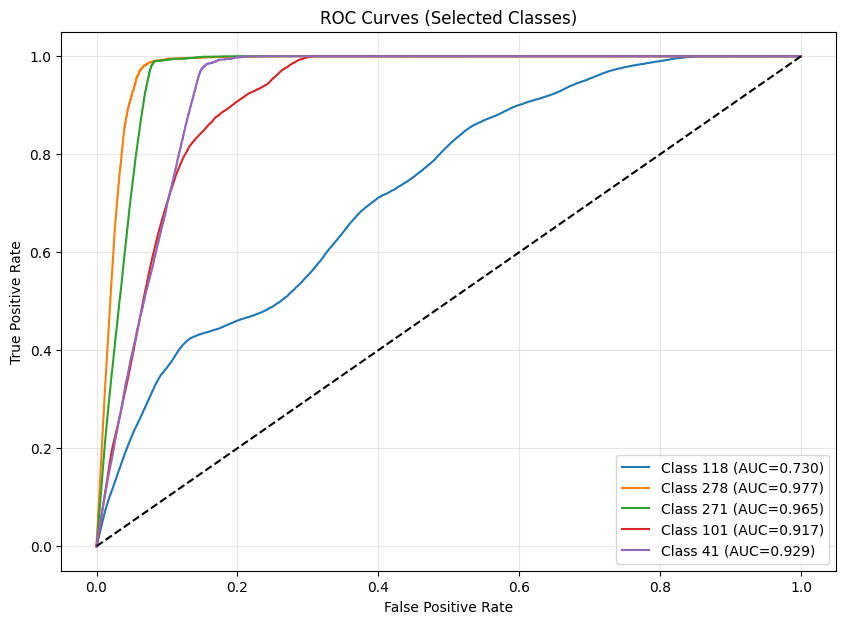

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

sample_classes = np.random.choice(classes, size=5, replace=False)

plt.figure(figsize=(10, 7))

for cls in sample_classes:
    i = np.where(classes == cls)[0][0]

    y_true_binary = (y_test == cls).astype(int)
    y_score = y_test_proba[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary, y_score)
    class_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {cls} (AUC={class_auc:.3f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Selected Classes)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


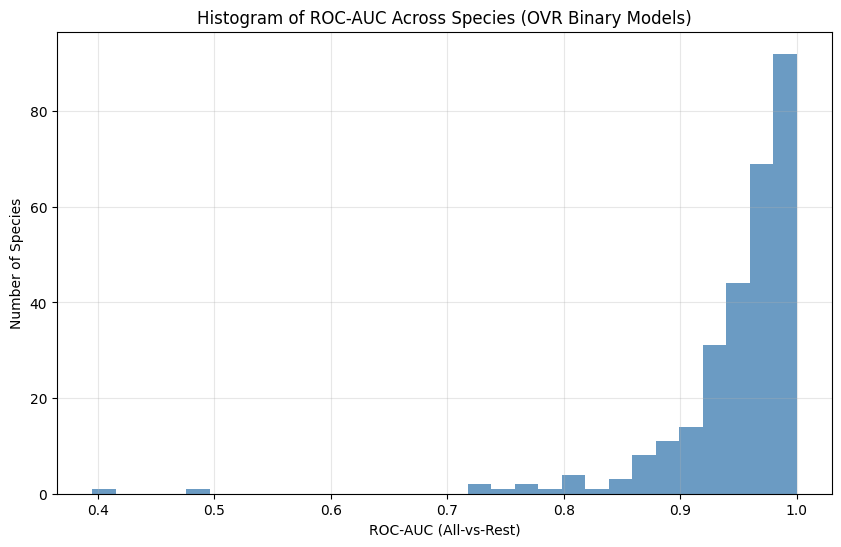

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

classes = np.unique(y_test)
auc_values = []

for i, cls in enumerate(classes):
    y_true = (y_test == cls).astype(int)
    y_score = y_test_proba[:, i]

    auc_i = roc_auc_score(y_true, y_score)
    auc_values.append(auc_i)

plt.figure(figsize=(10, 6))
plt.hist(auc_values, bins=30, color='steelblue', alpha=0.8)
plt.xlabel("ROC-AUC (All-vs-Rest)")
plt.ylabel("Number of Species")
plt.title("Histogram of ROC-AUC Across Species (OVR Binary Models)")
plt.grid(alpha=0.3)
plt.show()


2) Top-k Accuracy

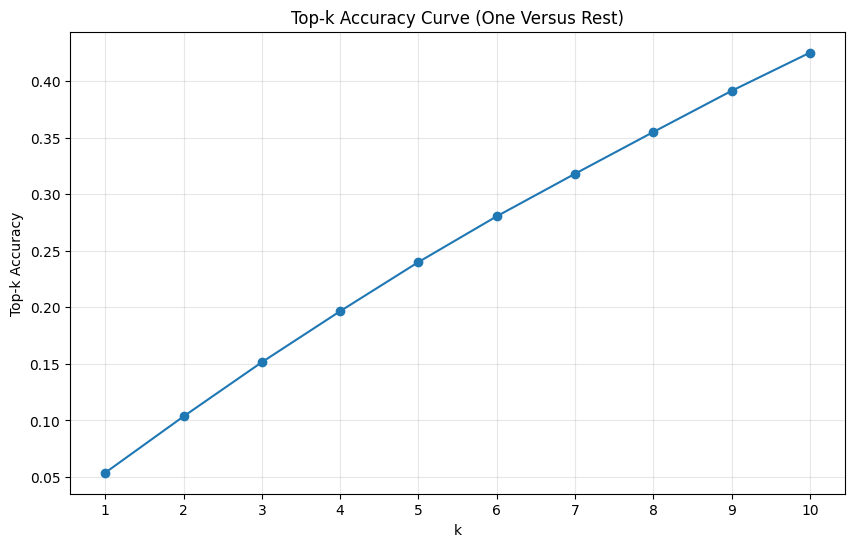

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Convert y_test to numpy
y_test_array = y_test.to_numpy()

ks = range(1, 11)

# Sort probabilities once (descending)
top_classes = np.argsort(-y_test_proba, axis=1)

topk_scores = []

for k in ks:
    pred_k = top_classes[:, :k]        # Top-k predicted class indices
    correct = np.any(pred_k == y_test_array[:, None], axis=1)
    topk_scores.append(correct.mean())

plt.figure(figsize=(10, 6))
plt.plot(ks, topk_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Top-k Accuracy")
plt.title("Top-k Accuracy Curve (One Versus Rest)")
plt.xticks(ks)
plt.grid(alpha=0.3)
plt.show()



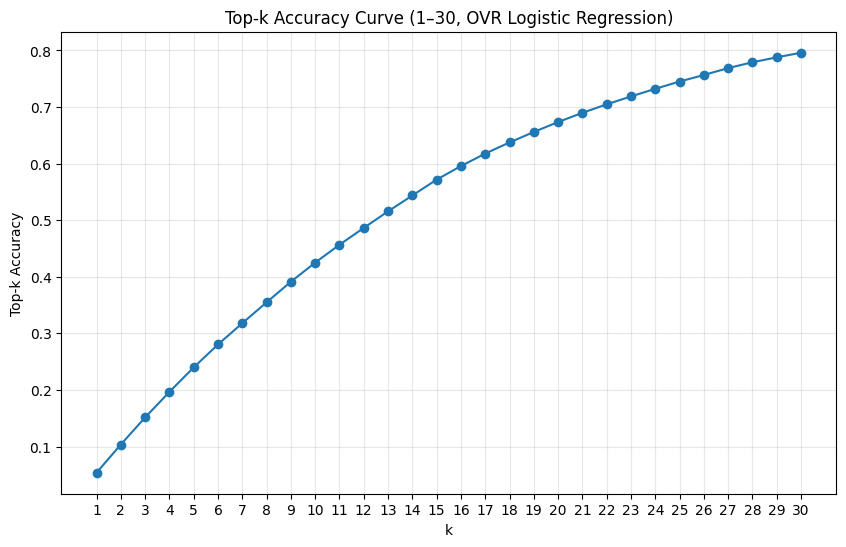

In [63]:
import numpy as np
import matplotlib.pyplot as plt

y_test_array = y_test.to_numpy()


#Each row sorted so highest-probability species come first
sorted_classes = np.argsort(-y_test_proba, axis=1)

# 3. Compute top-k accuracy
ks = range(1, 31)
topk_scores = []

for k in ks:
    pred_k = sorted_classes[:, :k]                          # top-k predictions
    correct_k = np.any(pred_k == y_test_array[:, None], axis=1)
    topk_scores.append(correct_k.mean())                    # accuracy for this k


# 4. Plot
plt.figure(figsize=(10, 6))
plt.plot(ks, topk_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Top-k Accuracy")
plt.title("Top-k Accuracy Curve (1–30, OVR Logistic Regression)")
plt.xticks(ks)
plt.grid(alpha=0.3)
plt.show()


3. False Negative Rate Per multiple Binary Classes: measures whether the model is consistent with the observed positives, but does not assess the model's behavior at other points.

In [57]:
import numpy as np

classes = np.unique(y_test)

fnr_species = {}

for i, cls in enumerate(classes):
    # Ground truth (1 = present, 0 = absent)
    y_true = (y_test == cls).astype(int)

    # Prediction (1 = predicted present)
    y_pred_bin = (y_test_pred == cls).astype(int)

    # Binary confusion components
    tp = np.sum((y_true == 1) & (y_pred_bin == 1))
    fn = np.sum((y_true == 1) & (y_pred_bin == 0))

    fnr_species[cls] = fn / (fn + tp + 1e-9)


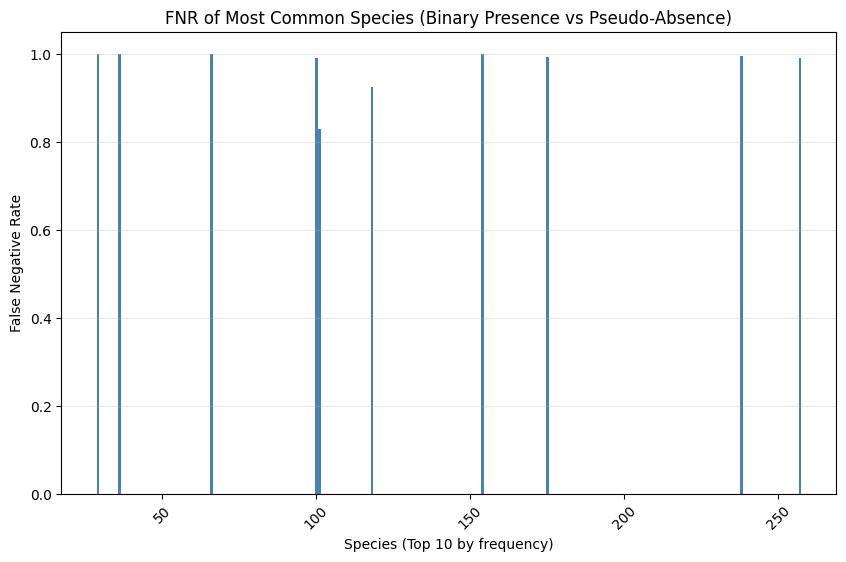

In [58]:
# Find the most common species in y_test
species_counts = y_test.value_counts()
top_species = species_counts.head(10).index

# Extract only those species' FNRs
top_fnr_values = [fnr_species[s] for s in top_species]

plt.figure(figsize=(10, 6))
plt.bar(top_species, top_fnr_values, color="steelblue")
plt.xlabel("Species (Top 10 by frequency)")
plt.ylabel("False Negative Rate")
plt.title("FNR of Most Common Species (Binary Presence vs Pseudo-Absence)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()


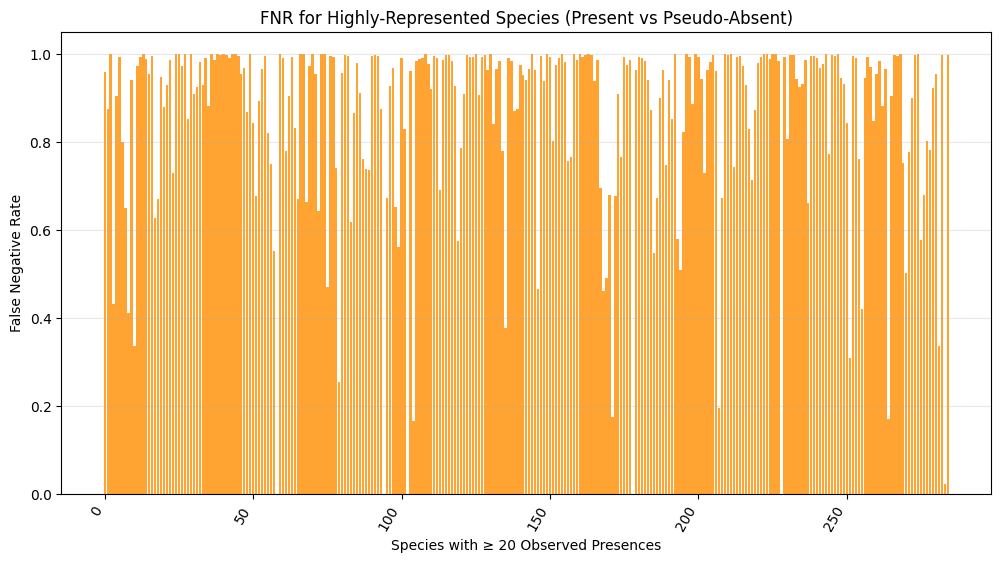

In [65]:
import pandas as pd

# Count how many times each species appears in the test set
counts = pd.Series(y_test).value_counts()

# Choose species with at least 20 positive samples
min_presence = 20
valid_species = counts[counts >= min_presence].index

fnr_values = []

for cls in valid_species:
    y_true = (y_test == cls).astype(int)
    y_pred_bin = (y_test_pred == cls).astype(int)

    tp = np.sum((y_true == 1) & (y_pred_bin == 1))
    fn = np.sum((y_true == 1) & (y_pred_bin == 0))

    fnr = fn / (fn + tp + 1e-9)
    fnr_values.append(fnr)

plt.figure(figsize=(12, 6))
plt.bar(valid_species, fnr_values, color="darkorange", alpha=0.8)
plt.xlabel("Species with ≥ 20 Observed Presences")
plt.ylabel("False Negative Rate")
plt.title("FNR for Highly-Represented Species (Present vs Pseudo-Absent)")
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()


Interpetation: Log Reg can rank species well, but cannot detect species as present as its too simplistic to capture 